# War Times EDA
This notebook analyzes UCDP data to understand conflict time range in Syrian cities. For this exercise we will be using the UCDP Georeferenced Event Dataset (GED) Global version 21.1. You can download the data here, and learn more about it [here](https://www.pcr.uu.se/research/ucdp/), and download the dataset (ZIP file) [here](https://ucdp.uu.se/downloads/ged/ged211-csv.zip). Please download and extract the contents into this directory. We will be working with the file **ged211.csv** for our analysis. We will also use a shapefile that contains bounds for all of our AOIs: **aois.gpkg**

In [106]:
import pandas as pd
import numpy as np
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


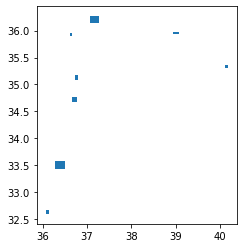

In [107]:
aois = gpd.read_file("data/aois.gpkg")
aois.plot();

In [94]:
ucdp = pd.read_csv('data/ged211.csv', low_memory=False)
ucdp = ucdp[['id', 'type_of_violence', 'conflict_name', 'country', 'adm_1', 'adm_2', 'date_start', 'latitude', 'longitude']]
ucdp = gpd.GeoDataFrame(ucdp, geometry=gpd.points_from_xy(ucdp.longitude, ucdp.latitude))
ucdp = ucdp.set_crs("epsg:4326")
ucdp_aoi = gpd.sjoin(ucdp, aois)


In [95]:
ucdp_aoi.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Int64Index: 22228 entries, 167744 to 244381
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   id                22228 non-null  int64   
 1   type_of_violence  22228 non-null  int64   
 2   conflict_name     22228 non-null  object  
 3   country           22228 non-null  object  
 4   adm_1             22228 non-null  object  
 5   adm_2             21337 non-null  object  
 6   date_start        22228 non-null  object  
 7   latitude          22228 non-null  float64 
 8   longitude         22228 non-null  float64 
 9   geometry          22228 non-null  geometry
 10  index_right       22228 non-null  int64   
 11  location          22228 non-null  object  
dtypes: float64(2), geometry(1), int64(3), object(6)
memory usage: 2.2+ MB


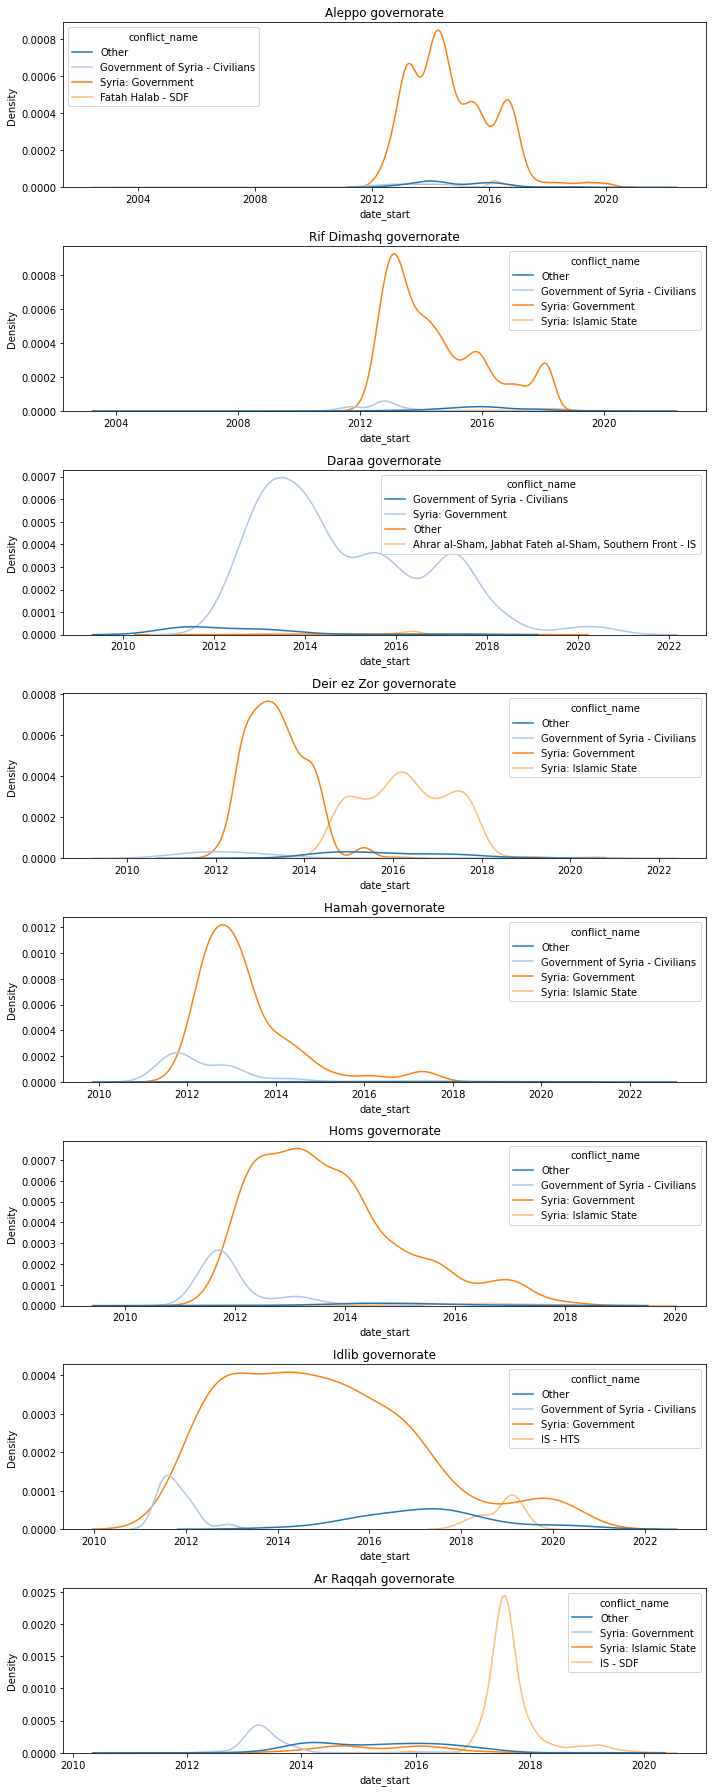

In [115]:
ucdp_aoi['date_start'] = pd.to_datetime(ucdp_aoi['date_start'])

fig, axes = plt.subplots(8,1, figsize=(10,25))
ax = axes.flatten()

for i in range(8):
    df = ucdp_aoi[ucdp_aoi['index_right'] == i]
    top_conflicts = df['conflict_name'].value_counts().index.tolist()[:3]
    df['conflict_name'] = np.where(df['conflict_name'].isin(top_conflicts), df['conflict_name'], 'Other')
    location = max(df['adm_1'])

    
#     sns.histplot(data = df, x='date_start', ax=ax[i], )
    sns.kdeplot(data=df, x="date_start", hue="conflict_name",  palette="tab20", ax=ax[i])
#     sns.kdeplot()
    
    ax[i].set_title(location)
plt.tight_layout()
